# $k\cdot p$ bulk bandstructure

## 1. Setup general settings

### 1.1 Import modules

In [62]:
%reload_ext autoreload
%autoreload 2

In [63]:
import kpy30band
print(f'kpy30band version = {kpy30band.__version__}')
#print(kpy30band.DataBase().print_database()) #print_materials_available_in_database()

kpy30band version = 0.0.2.dev1+g6dedfce57


In [64]:
from pathlib import Path
import os
import numpy as np
from collections import defaultdict
import h5py
import matplotlib.pyplot as plt
from kpy30band import k_dot_p, process_data, plottings

### 1.2 Matplotlib settings

In [65]:
params = {'figure.figsize': (8, 6), 'legend.fontsize': 18, 'axes.labelsize': 24, 'axes.titlesize': 24,
          'xtick.labelsize':24, 'xtick.major.width':2, 'xtick.major.size':5, 'ytick.labelsize': 24,
          'ytick.major.width':2, 'ytick.major.size':5, 'xtick.minor.width':2, 'xtick.minor.size':3,
          'ytick.minor.width':2, 'ytick.minor.size':3, 'errorbar.capsize':2, 'lines.markersize':12,
          'lines.linewidth':2, 'lines.linestyle':'-'}
plt.rcParams.update(params)
plt.rc('font', size=24)
plt_lw=2 # line width for line plots

### 1.3 Set project id (easy to track)

In [66]:
my_project_id = 'kp_simulations' 
sample_binaries = ['Sn', 'Ge'] # SnxGe1-x
sample_id = ''.join(sample_binaries)

### 1.4 Save data file path settings

In [67]:
save_f_dir = os.path.join(Path.home(),f'MyFolder/Projects/{my_project_id}/{sample_id}')
save_dataf_dir = f'{save_f_dir}/Data/'
save_figsf_dir = f'{save_f_dir}/Figs/'

os.makedirs(save_dataf_dir, exist_ok=True)
os.makedirs(save_figsf_dir, exist_ok=True)

In [68]:
save_figure = False
FigFormat = 'png'
FigDpi = 300

## 2. Set up simulation system information

### 2.1 Set $k$-path and compositions

In [69]:
# Which k-path to plot
kpath_list = ['L-G', 'G-X']
# Number of k-points in each section
nkpoints = 41
# Whether to calculate both energy values or eigenvectors of k.p Hamiltonian
calc_energy_only = True
# At which compositions to calculate
composition = [0.0, 1.0] #, 0.04, 0.12, 1.0] 
# If biaxial strain to use
pseudomorphic_strain = True 
# For biaxial strain what is the substrate
substrate = 'Si' # You can pass lattice constant of arbitrary substrate as well
# hkl direction of growth. biaxial strain is calculated based on this direction 
growth_direction = [0, 0, 1]
# Only calculate band energies for lowest 14 bands
cal_band_indices = [0, 14]

### 2.3 Run $k\cdot p$ calculations

#### 2.3.1 Initialize $k\cdot p$ Hamiltonian

In [70]:
use_this_params = 'default' #{'Sn': {'ED_dso': 0, 'ED_c': 0}, 'Ge': {'ED_dso': 0.00, 'lattice_a0':5.583}}

In [71]:
kp = k_dot_p(binaries=sample_binaries, pseudomorphic_strain=pseudomorphic_strain, 
             substrate=substrate, growth_direction_hkl=growth_direction,
             alloy_crystal_structure='zb', use_mat_params=use_this_params, 
             save_file_dir=save_dataf_dir)

#### 2.3.2 Calculate $k\cdot p$ energies at k-points

In [31]:
print(f'Compositions for {sample_binaries[0]}x{sample_binaries[1]}1-x = {", ".join([f"{x*100:0.2f}%" for x in composition])}')

Compositions for SnxGe1-x = 0.00%, 100.00%


In [40]:
ek_data = kp.kp_30x30(compositions=composition, overwrite_strain=0.02,
                      kpoints_list=kpath_list, nkpoints=nkpoints, 
                      return_energy_only=calc_energy_only,
                      cal_band_indices = cal_band_indices,
                      save_data=True, save_file='ek_data.h5')

## 3. Post processing

### 3.1 Load saved data

In [41]:
process_data_cls = process_data(save_file_dir=save_dataf_dir) 

In [42]:
for_compos = process_data_cls.process_ek_data('ek_data.h5', read_this_k_paths=['L-G', 'G-X']) # Default: read all bands

In [43]:
# Only true for unstrained systems (following band indexes are not valid for zero bandgap. change them.)
# In python indexing starts at 0
band_ids = {'CB_id': 8, 'CBp1_id': 10, 'CBp2_id': 12 , 'VBM_id': 5, 'VB2_id': 6, 'SO_id': 3} # 

In [44]:
for compos, (_,bands_e,_) in for_compos.items():
    CB_energy = bands_e[band_ids['CB_id'] ] 
    VB_energy = bands_e[band_ids['VBM_id']]
    G_energy = bands_e[:, nkpoints-1]

    comp = float(compos) # composition
    print(f'Sample: {sample_binaries[0]}{comp:0.2f}{sample_binaries[1]}{1.0-comp:0.2f}')
    print(f'\tBandgap     = {min(CB_energy): 0.3f} eV') 
    print(f'\tBandgap (G) = {G_energy[band_ids['CB_id']] - G_energy[band_ids['VBM_id']]  : 0.3f} eV') 
    print(f'\tBandgap2(G) = {G_energy[band_ids['CBp2_id']] - G_energy[band_ids['VBM_id']]  : 0.3f} eV') 
    print(f'\tDeltaSO (G) = {G_energy[band_ids['VB2_id']] - G_energy[band_ids['SO_id']]  : 0.3f} eV')
    print(f'\tE_L         = {CB_energy[0]  : 0.3f} eV')
    print(f'\tE_X         = {CB_energy[-1]  : 0.3f} eV')

Sample: Sn0.00Ge1.00
	Bandgap     =  0.618 eV
	Bandgap (G) =  0.687 eV
	Bandgap2(G) =  3.095 eV
	DeltaSO (G) =  0.459 eV
	E_L         =  0.619 eV
	E_X         =  0.828 eV
Sample: Sn1.00Ge0.00
	Bandgap     = -0.968 eV
	Bandgap (G) =  0.399 eV
	Bandgap2(G) =  3.218 eV
	DeltaSO (G) =  0.438 eV
	E_L         = -0.003 eV
	E_X         = -0.493 eV


## 4. Plottings

In [49]:
plt_kp = plottings(save_figure_dir=save_figsf_dir, log_info='1')

### 3.1 Plot band structure

In [50]:
plot_bands = None #None #[1,2,3,4,5,6]
set_energy_axis_limit = (-5, 5) #ymin, ymax

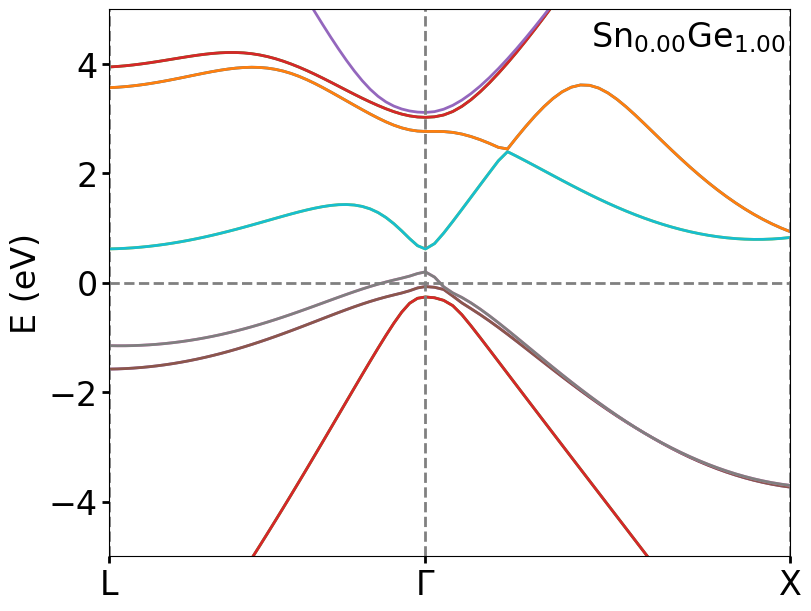

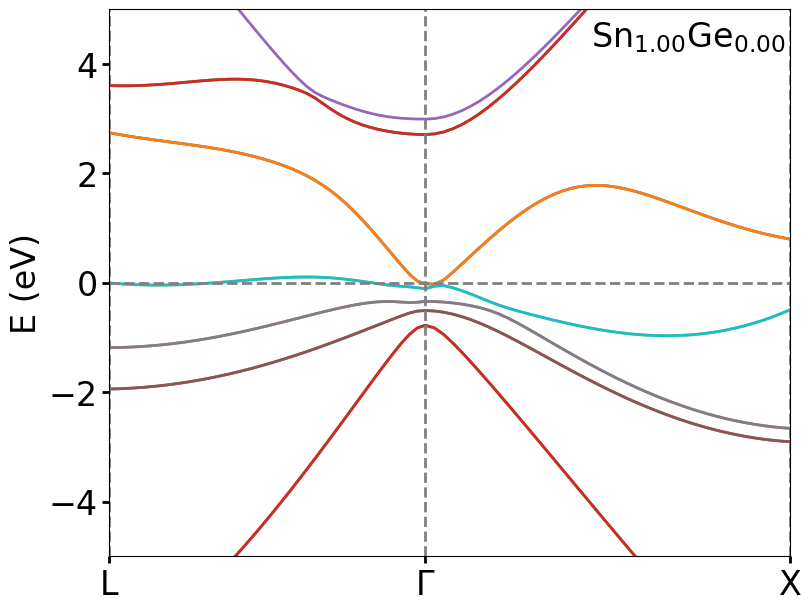

In [61]:
for compos, (kpts, bands_e, special_kpts) in for_compos.items():
    comp = float(compos) # composition
    sample_name = f'{sample_binaries[0]}$_{{{comp:0.2f}}}${sample_binaries[1]}$_{{{1-comp:0.2f}}}$'
    # file name of the figure to save
    save_fig_file = f'{sample_binaries[0]}{comp:0.2f}{sample_binaries[1]}{1.0-comp:0.2f}_LGX.{FigFormat}' 
    #===========================================================================================
    plt_kp.plot(kpts, bands_e, ymin=-5, ymax=5, special_kpts=special_kpts, color=None, 
                annotate_text={'text': sample_name, 'pos':(0.85,0.95)},
                savefig=save_figure, save_file_name=save_fig_file, dpi=FigDpi)